<a href="https://colab.research.google.com/github/ojaspaul123/DL-journey/blob/main/ANN/Data_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

Saving Social_Network_Ads.csv to Social_Network_Ads.csv


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
df = df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
import seaborn as sns

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

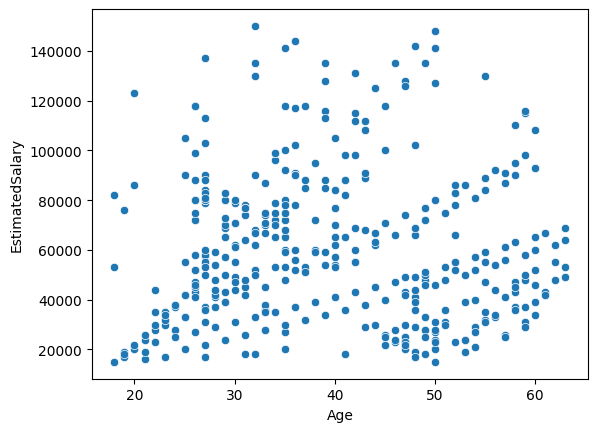

In [7]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1])

In [8]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [13]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=2))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [31]:
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4563 - loss: 102345.2734 - val_accuracy: 0.4125 - val_loss: 90787.8047
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4563 - loss: 61683.2305 - val_accuracy: 0.4125 - val_loss: 47725.7539
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4563 - loss: 29292.8633 - val_accuracy: 0.4125 - val_loss: 15426.6436
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4625 - loss: 5948.4053 - val_accuracy: 0.5875 - val_loss: 4823.3906
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5437 - loss: 3752.1438 - val_accuracy: 0.5875 - val_loss: 469.3299
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4625 - loss: 1066.4109 - val_accuracy: 0.5875 - val_loss: 299.1523
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5250 - loss: 684.9517 - val_accuracy: 0.4125 - val_loss: 1005.2725
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accu

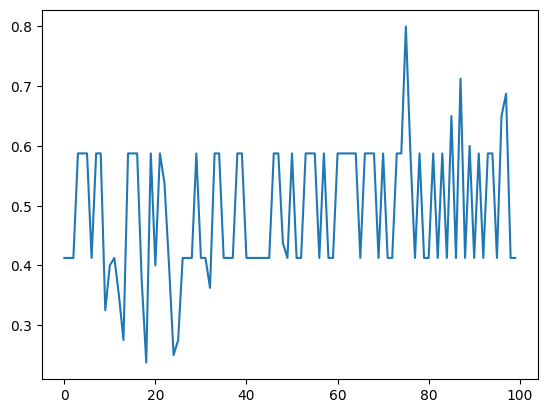

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_accuracy'])



**Applying Scaling**

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
X_train_scaled

array([[-1.08488446e+00, -4.98767871e-02],
       [ 5.04536628e-01, -1.01617446e+00],
       [ 1.17376656e+00, -6.16327146e-01],
       [ 2.53575404e-01,  1.64947429e+00],
       [-4.15654528e-01, -3.49762271e-01],
       [-4.15654528e-01,  5.49894181e-01],
       [ 8.62679208e-02,  1.31626820e+00],
       [ 1.50838152e+00,  1.21630637e+00],
       [ 8.39151594e-01, -1.14945689e+00],
       [ 1.50838152e+00, -3.83082880e-01],
       [-1.00123072e+00, -7.16288974e-01],
       [ 7.55497852e-01, -2.49800443e-01],
       [ 4.20882887e-01,  1.38290941e+00],
       [ 1.50838152e+00, -4.49724099e-01],
       [ 6.71844111e-01, -6.49647755e-01],
       [-9.17576976e-01, -1.14945689e+00],
       [-1.50315317e+00, -9.49533239e-01],
       [-9.17576976e-01, -4.98767871e-02],
       [-1.00123072e+00, -3.49762271e-01],
       [ 8.62679208e-02,  9.83062102e-01],
       [ 2.61417942e-03,  1.54951246e+00],
       [ 1.00645908e+00, -1.16518006e-01],
       [ 5.88190369e-01, -1.11613629e+00],
       [-1.

<Axes: >

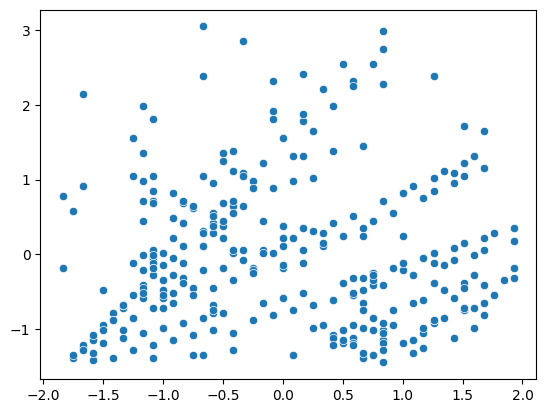

In [21]:
sns.scatterplot(x=X_train_scaled[:,0], y=X_train_scaled[:,1])

In [22]:
model = Sequential()

model.add(Dense(128, activation='relu', input_dim=2))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [29]:
history = model.fit(X_train_scaled, y_train, epochs=100, validation_data=(X_test_scaled, y_test))

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9781 - loss: 0.0593 - val_accuracy: 1.0000 - val_loss: 0.0420
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9781 - loss: 0.0590 - val_accuracy: 1.0000 - val_loss: 0.0424
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9781 - loss: 0.0591 - val_accuracy: 1.0000 - val_loss: 0.0430
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9781 - loss: 0.0592 - val_accuracy: 1.0000 - val_loss: 0.0426
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9781 - loss: 0.0589 - val_accuracy: 1.0000 - val_loss: 0.0425
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.9781 - loss: 0.0590 - val_accuracy: 1.0000 - val_loss: 0.0422
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9781 - loss: 0.0589 - val_accuracy: 1.0000 - val_loss: 0.0417
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.9781 - loss: 0.0590 - val_accuracy: 0.

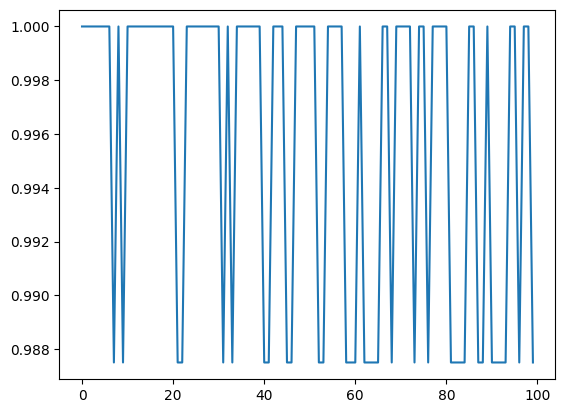

In [30]:
plt.plot(history.history['val_accuracy'])